<a href="https://colab.research.google.com/github/kaelasyadira/KaelaAssyuraSyadira-2311531001-ImageProcessing/blob/main/IP_TugasPertemuan4_2311531001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

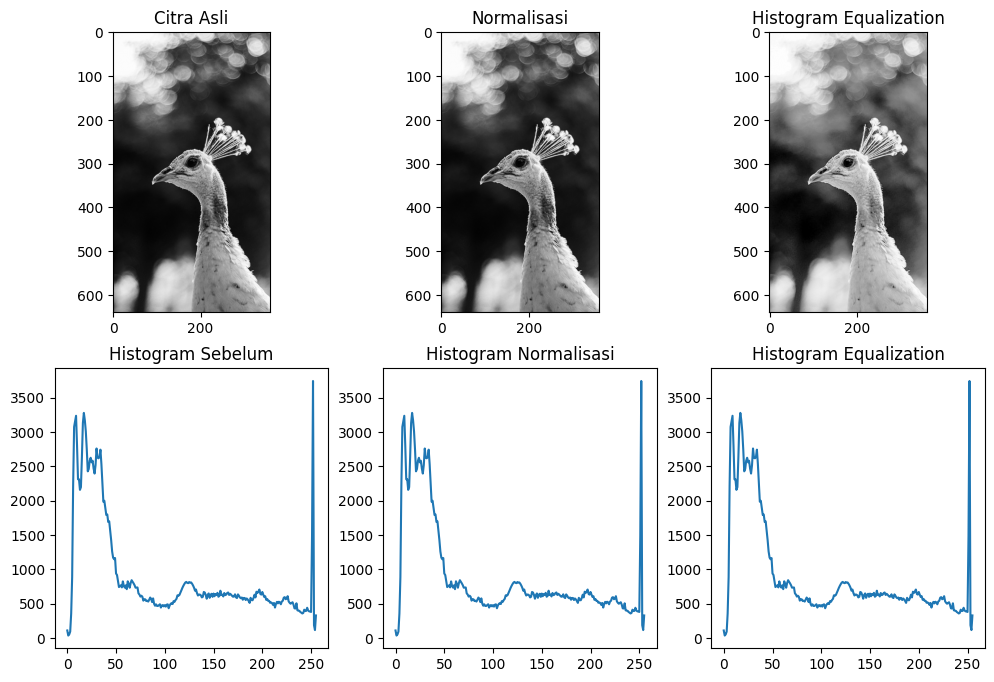

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('merak.jpg', 0)

hist_before = np.zeros(256)

for i in range(img.shape[0]):
    for j in range(img.shape[1]):
        hist_before[img[i,j]] += 1

min_val = np.min(img)
max_val = np.max(img)

norm_img = ((img - min_val) / (max_val - min_val)) * 255
norm_img = norm_img.astype(np.uint8)

hist_norm = np.zeros(256)

for i in range(norm_img.shape[0]):
    for j in range(norm_img.shape[1]):
        hist_norm[norm_img[i,j]] += 1

hist = np.zeros(256)

for i in range(norm_img.shape[0]):
    for j in range(norm_img.shape[1]):
        hist[norm_img[i,j]] += 1

pdf = hist / (norm_img.shape[0] * norm_img.shape[1])

cdf = np.zeros(256)
cdf[0] = pdf[0]

for i in range(1,256):
    cdf[i] = cdf[i-1] + pdf[i]

eq_img = np.zeros_like(norm_img)

for i in range(norm_img.shape[0]):
    for j in range(norm_img.shape[1]):
        eq_img[i,j] = int(cdf[norm_img[i,j]] * 255)

plt.figure(figsize=(12,8))

plt.subplot(2,3,1)
plt.title("Citra Asli")
plt.imshow(img, cmap='gray')

plt.subplot(2,3,2)
plt.title("Normalisasi")
plt.imshow(norm_img, cmap='gray')

plt.subplot(2,3,3)
plt.title("Histogram Equalization")
plt.imshow(eq_img, cmap='gray')

plt.subplot(2,3,4)
plt.title("Histogram Sebelum")
plt.plot(hist_before)

plt.subplot(2,3,5)
plt.title("Histogram Normalisasi")
plt.plot(hist_norm)

plt.subplot(2,3,6)
plt.title("Histogram Equalization")
plt.plot(hist)

plt.show()